#### polynomial regresion

Вам необходимо последовательно решить несколько задачи 1,2,3 
заменяя None на программный код

You need to solve tasks 1,2,3 replacing None to correct program code

In [13]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import time

#### Create syntetic dataset


In [2]:
def f(x):
    #return x*np.sin(x*4*3.141)+1
    return x*x*np.sin(x*2*3.141)+x+5

In [3]:
def plusRandomValues(x,y):
    num= x.size
    r=np.array([np.random.rand(num)]).T/30
    x=x+r
    r=np.array([np.random.rand(num)]).T/30
    y=y+r
    return x,y

###### Support function


In [4]:
def x_degree(x,degree):   #PolynomialFeatures(degree)
    on=np.ones([m,1])
    X=on
    for i in range(degree):
        xx=np.power(x, i+1)
        X=np.concatenate((X,xx),axis=1)
    return X

###### Task 1.1. Реализуйте алгоритм градиентного спуска для вычисления параметров регрессии 4-го порядка. 
###### Task 1.2. Вывод результатов примерно как на рисунке.


In [5]:
# replace None to program code
# замените None на программный код

180
Средняя квадратичная ошибка регрессии =  0.024887914696937814
Расчет регрессии занял  0.0010089874267578125  секунд
Средняя квадратичная ошибка: 0.0249
R²: 0.32


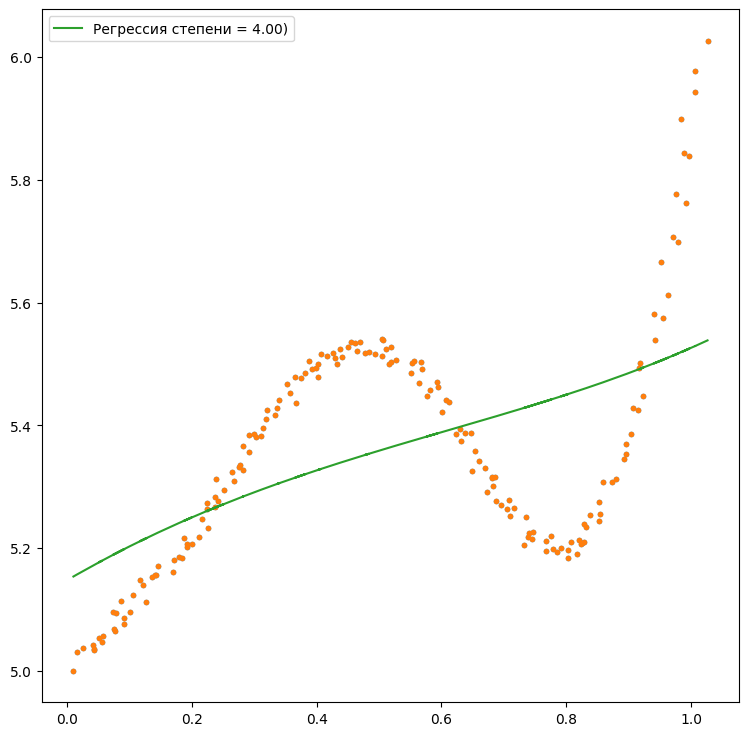

In [6]:
# замените None на программный код
xr = np.array([np.linspace(0, 1, 180)])
x = xr.T
print(x.size)

# Генерация целевых значений с добавленным случайным шумом
y = f(x)
(x, y) = plusRandomValues(x, y)  # добавление случайных величин

plt.figure(figsize=(9, 9))
plt.plot(x, y, '.')

m = x.size
degree = 4  # степень/коэффициент регрессии

# Создание полиномиальных признаков (матрица X)
X = x_degree(x, degree)  # Полиномиальное расширение для 4-го порядка

# Инициализация случайных параметров theta (коэффициентов)
theta = np.random.rand(degree + 1, 1)

# Функция гипотезы (начальная)
h = np.dot(X, theta)

# Установка скорости обучения и количества итераций для градиентного спуска
alpha = 0.9
iterations = 100

# Градиентный спуск
t0 = time.time()
for i in range(iterations):
    # Вычисление градиента и обновление theta
    gradient = (1/m) * np.dot(X.T, (h - y))
    theta = theta - alpha * gradient  # None Обновление theta на основе градиента
    h = np.dot(X, theta)  # Переисчисление гипотезы с обновленным theta

# Финальная гипотеза (предсказанные значения y)
h = np.dot(X, theta)
t1 = time.time()

# Построение графика исходных данных и линии регрессии
plt.plot(x, y, '.')
plt.plot(x, h, label='Регрессия степени = {:0.2f})'.format(degree))
plt.legend()

# Вычисление средней квадратичной ошибки (MSE)
mse = np.mean((h - y) ** 2) # None
print('Средняя квадратичная ошибка регрессии = ', mse)
print('Расчет регрессии занял ', (t1 - t0), ' секунд')

# Использование метрик sklearn для дальнейшей проверки
from sklearn.metrics import mean_squared_error, r2_score

y_predict = h  # None Предсказанные значения нашей модели
y_test = y  # None Фактические целевые значения

# Вычисление и вывод средней квадратичной ошибки и R²
print("Средняя квадратичная ошибка: {:.4f}".format(mean_squared_error(y_test, y_predict)))
print("R²: {:.2f}".format(r2_score(y_test, y_predict)))


###### Task 2: calculate regression parameters using matrix equation\рассчитайте параметры регрессии матричным способом

Task 2: Добавьте регуляризационный
коэффициент

Вам необходимо изменить алгоритм градиентного спуска в соответствии с
выражением
2.7


In [7]:
def f(x):
    #return x*np.sin(x*4*3.141)+1
    return x*x*np.sin(x*6*3.141)+x+5
def plusRandomValues(x,y):
    num= x.size
    r=np.array([np.random.rand(num)]).T/10
    x=x+r
    r=np.array([np.random.rand(num)]).T/10
    y=y+r
    return x,y

180
Средняя квадратичная ошибка регрессии =  0.4150205741297708
Расчет регрессии занял  0.0010006427764892578  секунд
Средняя квадратичная ошибка: 0.4150
R²: -2.17


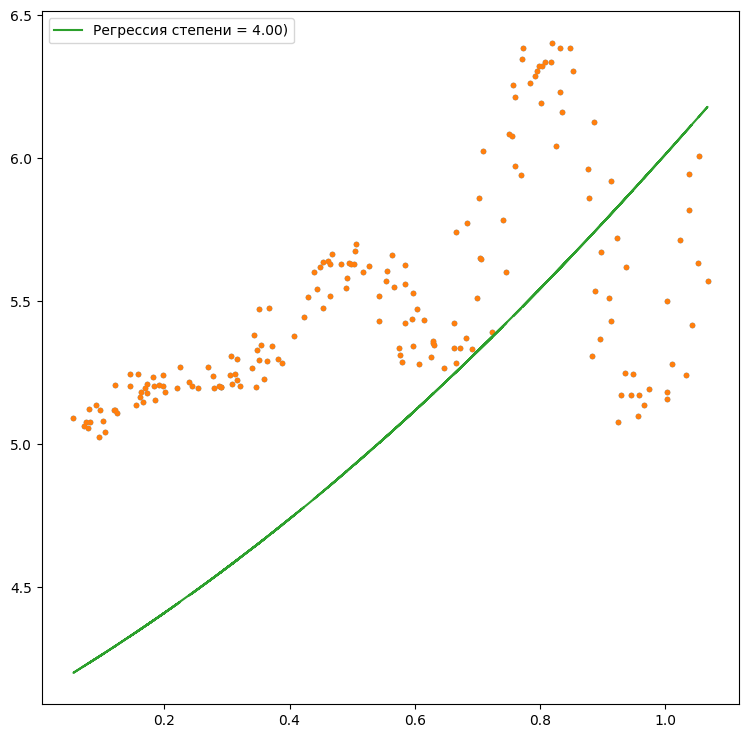

In [8]:
#Your code here
# Use program code of previous task
# Обновленная функция f с изменением амплитуды
def f(x):
    return x*x*np.sin(x*6*3.141) + x + 5

# Функция для добавления случайных значений
def plusRandomValues(x, y):
    num = x.size
    r = np.array([np.random.rand(num)]).T / 10
    x = x + r
    r = np.array([np.random.rand(num)]).T / 10
    y = y + r
    return x, y

# Замените None на программный код
xr = np.array([np.linspace(0, 1, 180)])
x = xr.T
print(x.size)

# Генерация целевых значений с добавленным случайным шумом
y = f(x)
(x, y) = plusRandomValues(x, y)  # добавление случайных величин

plt.figure(figsize=(9, 9))
plt.plot(x, y, '.')

m = x.size
degree = 4  # степень/коэффициент регрессии

# Создание полиномиальных признаков (матрица X)
X = x_degree(x, degree)  # Полиномиальное расширение для 4-го порядка

# Инициализация случайных параметров theta (коэффициентов)
theta = np.random.rand(degree + 1, 1)

# Установка скорости обучения, регуляризационного коэффициента и количества итераций
alpha = 0.1
lambda_reg = 0.1  # Регуляризационный коэффициент
iterations = 100

# Градиентный спуск с L2-регуляризацией
t0 = time.time()
for i in range(iterations):
    h = np.dot(X, theta)  # Предсказанные значения
    gradient = (1/m) * np.dot(X.T, (h - y)) + lambda_reg * theta  # Добавление регуляризации
    theta = theta - alpha * gradient  # Обновление theta на основе градиента

# Получение предсказанных значений после градиентного спуска
h = np.dot(X, theta)
t1 = time.time()

# Построение графика
plt.plot(x, y, '.')
plt.plot(x, h, label='Регрессия степени = {:0.2f})'.format(degree))
plt.legend()

# Вычисление средней квадратичной ошибки (MSE)
mse = np.mean((h - y) ** 2)
print('Средняя квадратичная ошибка регрессии = ', mse)
print('Расчет регрессии занял ', (t1 - t0), ' секунд')

# Использование метрик sklearn для дальнейшей проверки
from sklearn.metrics import mean_squared_error, r2_score

y_predict = h  # Предсказанные значения нашей модели
y_test = y  # Фактические целевые значения

# Вычисление и вывод средней квадратичной ошибки и R²
print("Средняя квадратичная ошибка: {:.4f}".format(mean_squared_error(y_test, y_predict)))
print("R²: {:.2f}".format(r2_score(y_test, y_predict)))


Task 2: Добавьте регуляризационный коэффициент 

Вам необходимо изменить алгоритм градиентного спуска в соответствии с выражением 2.7

In [9]:
def f(x):
    #return x*np.sin(x*4*3.141)+1
    return x * x * np.sin(x * 6 * 3.141) + x + 5


def plusRandomValues(x, y):
    num = x.size
    r = np.array([np.random.rand(num)]).T / 10
    x = x + r
    r = np.array([np.random.rand(num)]).T / 10
    y = y + r
    return x, y

180
Средняя квадратичная ошибка регрессии =  0.4208644807597113
Расчет регрессии занял  0.002001047134399414  секунд
Средняя квадратичная ошибка: 0.4209
R²: -2.26


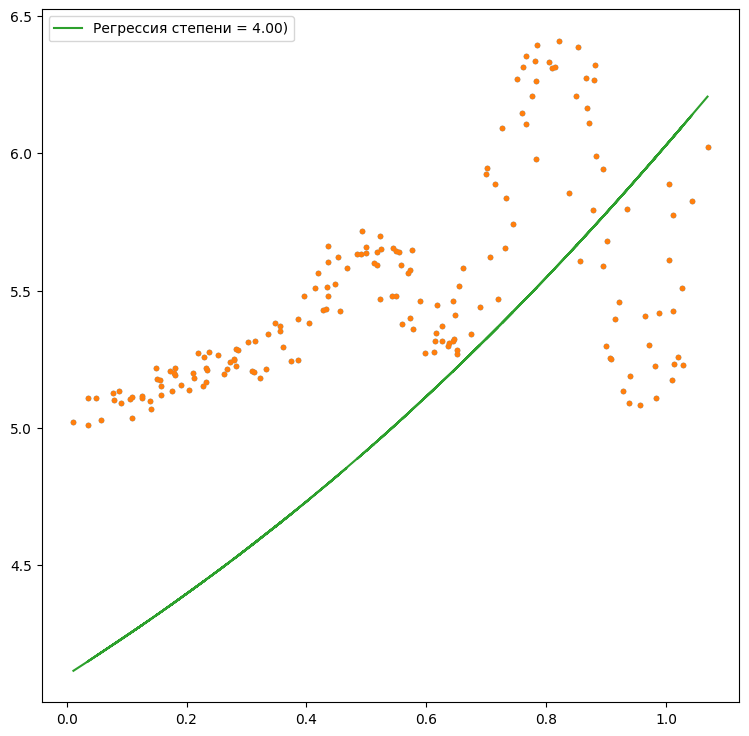

In [10]:
#Your code here
# Use program code of previous task
# Обновленная функция f с изменением амплитуды
def f(x):
    return x*x*np.sin(x*6*3.141) + x + 5

# Функция для добавления случайных значений
def plusRandomValues(x, y):
    num = x.size
    r = np.array([np.random.rand(num)]).T / 10
    x = x + r
    r = np.array([np.random.rand(num)]).T / 10
    y = y + r
    return x, y

# Замените None на программный код
xr = np.array([np.linspace(0, 1, 180)])
x = xr.T
print(x.size)

# Генерация целевых значений с добавленным случайным шумом
y = f(x)
(x, y) = plusRandomValues(x, y)  # добавление случайных величин

plt.figure(figsize=(9, 9))
plt.plot(x, y, '.')

m = x.size
degree = 4  # степень/коэффициент регрессии

# Создание полиномиальных признаков (матрица X)
X = x_degree(x, degree)  # Полиномиальное расширение для 4-го порядка

# Инициализация случайных параметров theta (коэффициентов)
theta = np.random.rand(degree + 1, 1)

# Установка скорости обучения, регуляризационного коэффициента и количества итераций
alpha = 0.1
lambda_reg = 0.1  # Регуляризационный коэффициент
iterations = 100

# Градиентный спуск с L2-регуляризацией
t0 = time.time()
for i in range(iterations):
    h = np.dot(X, theta)  # Предсказанные значения
    gradient = (1/m) * np.dot(X.T, (h - y)) + lambda_reg * theta  # Добавление регуляризации
    theta = theta - alpha * gradient  # Обновление theta на основе градиента

# Получение предсказанных значений после градиентного спуска
h = np.dot(X, theta)
t1 = time.time()

# Построение графика
plt.plot(x, y, '.')
plt.plot(x, h, label='Регрессия степени = {:0.2f})'.format(degree))
plt.legend()

# Вычисление средней квадратичной ошибки (MSE)
mse = np.mean((h - y) ** 2)
print('Средняя квадратичная ошибка регрессии = ', mse)
print('Расчет регрессии занял ', (t1 - t0), ' секунд')

# Использование метрик sklearn для дальнейшей проверки
from sklearn.metrics import mean_squared_error, r2_score


y_predict = h  # Предсказанные значения нашей модели
y_test = y  # Фактические целевые значения

# Вычисление и вывод средней квадратичной ошибки и R²
print("Средняя квадратичная ошибка: {:.4f}".format(mean_squared_error(y_test, y_predict)))
print("R²: {:.2f}".format(r2_score(y_test, y_predict)))
